In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [4]:
class linear_regression_multiple_features:
    def __init__(self, size, b, learning_rate):
        self.x = None 
        self.y = None 
        self.size = size
        self.w = self.initial_w_parameters()
        self.b = b
        self.alpha = learning_rate 

    def initial_w_parameters(self):
        self.w = np.zeros(self.size)

    def generate_sample_data(self, sample_count):

        np.random.seed(42)
        
        self.x = np.random.rand(sample_count, self.size)  # sample_count rows, self.size columns (features)

        feature_ranges = []
        for _ in range(self.size):
            min_val = np.random.uniform(0, 10)  # Random min value between 0 and 50
            max_val = np.random.uniform(min_val + 10, min_val + 90)  # Random max, ensuring it's greater than min_val by at least 10
            feature_ranges.append((min_val, max_val))
        
        
        # Step 3: Scale each feature (column) to its respective range
        for i in range(self.size):
            min_val, max_val = feature_ranges[i]
            self.x[:, i] = self.x[:, i] * (max_val - min_val) + min_val  # Scale to [min_val, max_val]
        
        # True weights for each feature (for generating the target y)
        true_weights = np.random.rand(self.size)  # One weight for each feature
        print(f"this is the true parameters for \"w\" {true_weights}")
        
        # True intercept aka "b" parameter 
        true_intercept = 100
        print(f"true \"b\" parameter value {true_intercept}")

        # Generate random scaling factors for each feature, between 10 and 50
        noise_scaling_factors = np.random.uniform(0.1, 1, self.size)
        
        # Adding random noise
        noise = np.random.randn(sample_count, self.size) * noise_scaling_factors  # Random noise to simulate real-world data

        # Sum noise across the feature axis to match the shape of the outcome (200,)
        noise_sum = np.sum(noise, axis=1) # this is to make the dimensions into becoming 1D 
        
        # produces a single column with multiple rows for real outcomes 
        self.y = np.dot(self.x, true_weights) + true_intercept + noise_sum

        return true_weights, true_intercept

    def plot_sample_data(self):
        for i in range(self.x.shape[1]):
            plt.scatter(self.x[:, i], self.y, label=f'Feature {i+1}')
            plt.xlabel(f'Feature {i+1}')
            plt.ylabel('Target (y)')
            plt.title(f'Feature {i+1} vs Target')
            plt.show()

    def linear_regression_predict(self):
        # equation_linear_regression = np.dot(self.w, self.x) + self.b # i think it's ok if i don't use dot product here 
        # np.dot(self.w, self.x) only works if they have same dimension for both row and columns but we only wanna mulitply self.x with self.w
            # what will np.dot produce tho? same dimension as in same column and rows or just return 1D? 
        # equation_linear_regression = self.x.dot(self.w) + self.b # this is how we multiply each row in data x with each corresponding weight
        # basically np.dot and self.x.dot is the same. self.x.dot is the shortcut syntax for it. 
        equation_linear_regression = np.dot(self.x, self.w) + self.b
        return equation_linear_regression

    def optimize(self, count):
        
        m = len(self.x)
        optimize_w = np.zeros(self.size)
        
        for i in range(count):
            error = self.linear_regression_predict() - self.y

            for j in range(self.size):
                optimize_w[j] = 1/m * np.sum(error * self.x[:, j]) # this array slicing thing is what i have learned
            
            optimize_b = 1/m * np.sum(error)
            
            self.w = self.w - self.alpha * optimize_w
            self.b = self.b - self.alpha * optimize_b


    def plot_final_data(self):
        for i in range(self.x.shape[1]):
            plt.scatter(self.x[:, i], self.y, label=f'Feature {i+1}')
            plt.xlabel(f'Feature {i+1}')
            plt.ylabel('Target (y)')
            plt.title(f'Feature {i+1} vs Target')
            plt.plot(self.x[:, i], self.linear_regression_predict(self.w[i]), color='red', label='Fitted Line')
            plt.legend()
            plt.grid(True)
            plt.show()

    def feature_scale(self):
        shape_x = self.x.shape[1]
        max_array_x = np.empty(shape_x)
        max_y = max(self.y)

        for i in range(shape_x):
            max_array_x[i] = max(self.x[:, i])

        scaled_x = np.divide(self.x, max_array_x)
        scaled_y = np.divide(self.y, max_y)
            
        return scaled_x, scaled_y
        


this is the true parameters for "w" [0.22120944 0.98766801 0.94405934 0.03942681 0.70557517]
true "b" parameter value 100


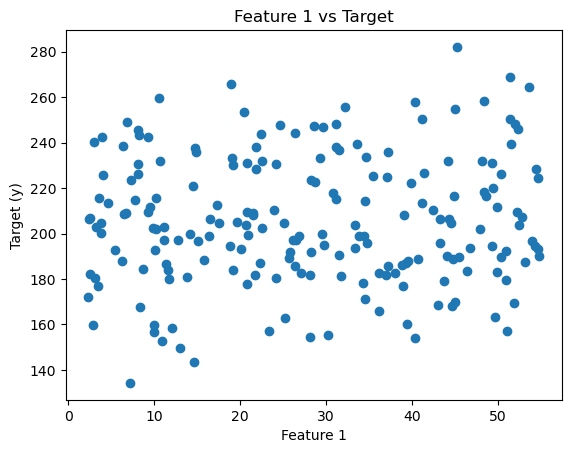

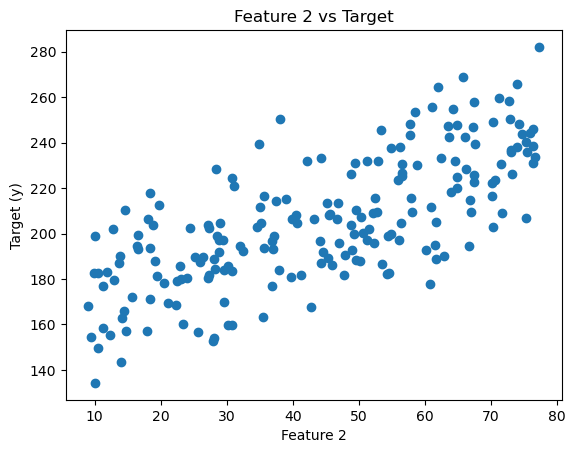

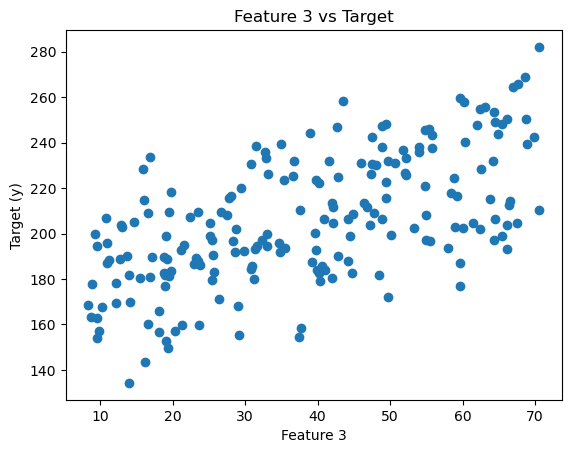

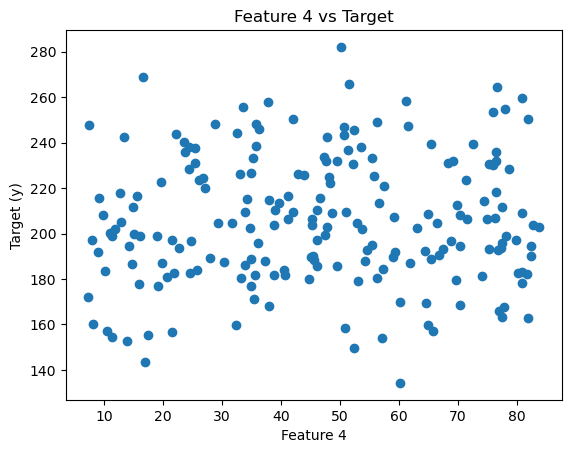

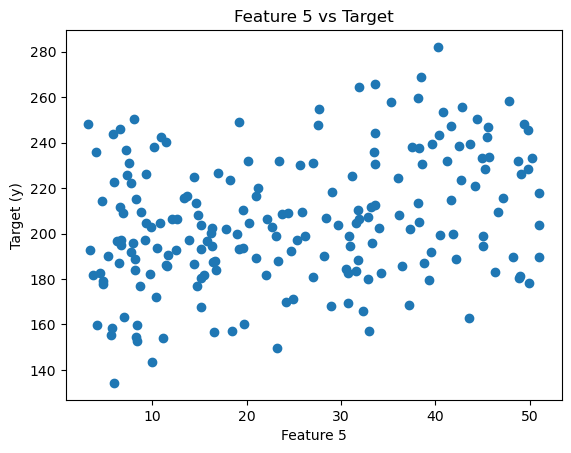

In [6]:
model = linear_regression_multiple_features(5, 0, 0.0001)
model.initial_w_parameters()
true_weights, true_intercept = model.generate_sample_data(200)
model.plot_sample_data()

In [10]:
"""
total time taken before scaled.
"""


start_time = time.time()

count = len(model.x) * 10
print(f"this is the count that will be used in loop: {count}")
model.optimize(count)
print(f"this is model parameter for w: {model.w}")
print(f"this is model parameter for b: {model.b}")
print(f"real paramters for w: {true_weights}")
print(f"real parameter for b: {true_intercept}")


end_time = time.time()  # Stop the timer
elapsed_time = end_time - start_time  # Calculate elapsed time

print(f"Elapsed time: {elapsed_time:.4f} seconds")


this is the count that will be used in loop: 2000
this is model parameter for w: [0.21379409 0.98245404 0.93487849 0.03382375 0.70639993]
this is model parameter for b: 101.37112350954109
real paramters for w: [0.22120944 0.98766801 0.94405934 0.03942681 0.70557517]
real parameter for b: 100
Elapsed time: 0.0970 seconds


In [26]:
"""
below code is just to get an idea of what might the scaled version of x and y would look like.

"""

# print(model.x)
# print("==========")
# print(model.y)
# print("-------------------------------------------------------------------")
scaled_x, scaled_y = model.feature_scale()
# print(scaled_x)
# print("==========")
# print(scaled_y)
model.x = scaled_x 
model.y = scaled_y